## Analysis Notebook

### Setup

In [211]:
import json
import numpy as np
import pandas as pd
from pathlib import PurePath
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import os

TOP_LEVEL_DIR = PurePath(os.getcwd())

RAW_DATA_DIR = PurePath(TOP_LEVEL_DIR / "cfb-data")
CLEANED_DATA_DIR = PurePath(TOP_LEVEL_DIR / "cleaned-data")

nfl_data: dict = json.load(open(PurePath(CLEANED_DATA_DIR) / "nfl_player_data.json"))
cfb_data: dict = json.load(open(PurePath(CLEANED_DATA_DIR) / "cfb_player_data.json"))


stat_categories = (
    "passing",
    "rushing",
    "receiving",
    "defense",
    "kicking",
    "punting",
    "returns",
)


def merge_two_dicts(x: dict, y: dict) -> dict:
    """Given two dictionaries, merge them into a new dict as a shallow copy.

    Params
    ------
    x: dict
        The first dictionary to merge.
    y: dict
        The second dictionary to merge.

    Returns
    -------
    dict
        A new dictionary that is a shallow copy of the two dictionaries.
    """

    z = x.copy()
    z.update(y)
    return z

### Combine datasets for players in both

In [212]:
combined_data = {}

for nfl_player in nfl_data.keys():
    if nfl_player in cfb_data:
        player_id = nfl_data[nfl_player]["player_id"]
        if not np.isnan(player_id):
            combined_data[nfl_player] = {
                "player_id": player_id,
                "years_played": cfb_data[nfl_player]["years_played"]
                + nfl_data[nfl_player]["years_played"],
                "age": nfl_data[nfl_player]["age"],
                "team": nfl_data[nfl_player]["team"],
                "position": nfl_data[nfl_player]["position"],
                "player_stats": merge_two_dicts(
                    cfb_data[nfl_player]["player_stats"],
                    nfl_data[nfl_player]["player_stats"],
                ),
            }

### Sort by position

In [213]:
unique_positions = set(
    combined_data[player]["position"] for player in combined_data.keys()
)


def get_position_data(position: str, year: int) -> pd.DataFrame:
    """Given a position, return the data for that position.

    Params
    ------
    position: str
        The position to get data for.
    year: int
        The year to get data for.

    Returns
    -------
    dict
        The data for the given position.
    """

    position_data = {}
    for player in combined_data.keys():
        if combined_data[player]["position"] == position:
            if str(year) in combined_data[player]["player_stats"].keys():
                position_data[player] = {
                    "player_id": combined_data[player]["player_id"],
                    "years_played": combined_data[player]["years_played"],
                    "age": combined_data[player]["age"],
                    "team": combined_data[player]["team"],
                    "position": combined_data[player]["position"],
                }
                position_data[player] = position_data[player] | {
                    stat_type: stat_value
                    for stat_type, stat_value in combined_data[player]["player_stats"][
                        str(year)
                    ].items()
                }

    defense_positions = ["DL", "LB", "DB", "S", "CB", "OLB", "ILB"]

    if position == "QB":
        position_data = {
            player: {**position_data[player], **position_data[player]["passing"]}
            for player in position_data.keys()
            if "passing" in position_data[player].keys()
        }
    elif position == "RB":
        position_data = {
            player: {**position_data[player], **position_data[player]["rushing"]}
            for player in position_data.keys()
            if "rushing" in position_data[player].keys()
        }
    elif position == "WR":
        position_data = {
            player: {**position_data[player], **position_data[player]["receiving"]}
            for player in position_data.keys()
            if "receiving" in position_data[player].keys()
        }
    elif position == "TE":
        position_data = {
            player: {**position_data[player], **position_data[player]["receiving"]}
            for player in position_data.keys()
            if "receiving" in position_data[player].keys()
        }
    elif position in defense_positions:
        position_data = {
            player: {**position_data[player], **position_data[player]["defense"]}
            for player in position_data.keys()
            if "defense" in position_data[player].keys()
        }

    return (
        pd.DataFrame.from_dict(position_data, orient="index")
        .drop(
            [stat_category for stat_category in stat_categories if stat_category],
            axis=1,
            errors="ignore",
        )
        .dropna(axis=1)
    )


WR_data = get_position_data("WR", 2017)
RB_data = get_position_data("RB", 2016)
TE_data = get_position_data("TE", 2018)
QB_data = get_position_data("QB", 2018)

### Make some graphs

In [214]:
def calc_kmeans(data, k, seed, epsilon):
    np.random.seed(seed)
    centers = data[np.random.choice(range(len(data)), k, replace=False)]
    centers_prev = np.zeros(centers.shape)
    num_iterations = 0
    while np.linalg.norm(centers - centers_prev) > epsilon:
        np.copyto(
            centers_prev, centers
        )  # centers_prev is the dest and centers is the src
        num_iterations += 1
        # step 2 : cluster the data by grouping points that are closest to the same center
        distances = np.zeros((len(data), k))
        for i in range(k):
            distances[:, i] = np.linalg.norm(data - centers[i], axis=1)
        clusters = np.argmin(distances, axis=1)
        # step 3 : recompute the cluster centers by averaging the points in the cluster
        for i in range(k):
            data_i = data[clusters == i]
            if len(data_i):
                centers[i] = (1 / len(data_i)) * np.sum(data_i, axis=0)

    return (centers, clusters, num_iterations)


def calc_cost(data, centers, clusters):
    cost = 0
    for j in range(len(centers)):
        cost += np.sum(pow(np.linalg.norm(data[clusters == j] - centers[j], axis=1), 2))

    return cost


def compute_elbow(data, k_max, seed, epsilon):
    costs = np.zeros(k_max)
    for k in range(1, k_max + 1):
        centers, clusters, num_iterations = calc_kmeans(data, k, seed, epsilon)
        costs[k - 1] = calc_cost(data, centers, clusters)
    return costs


X axis: yds
Y axis: age


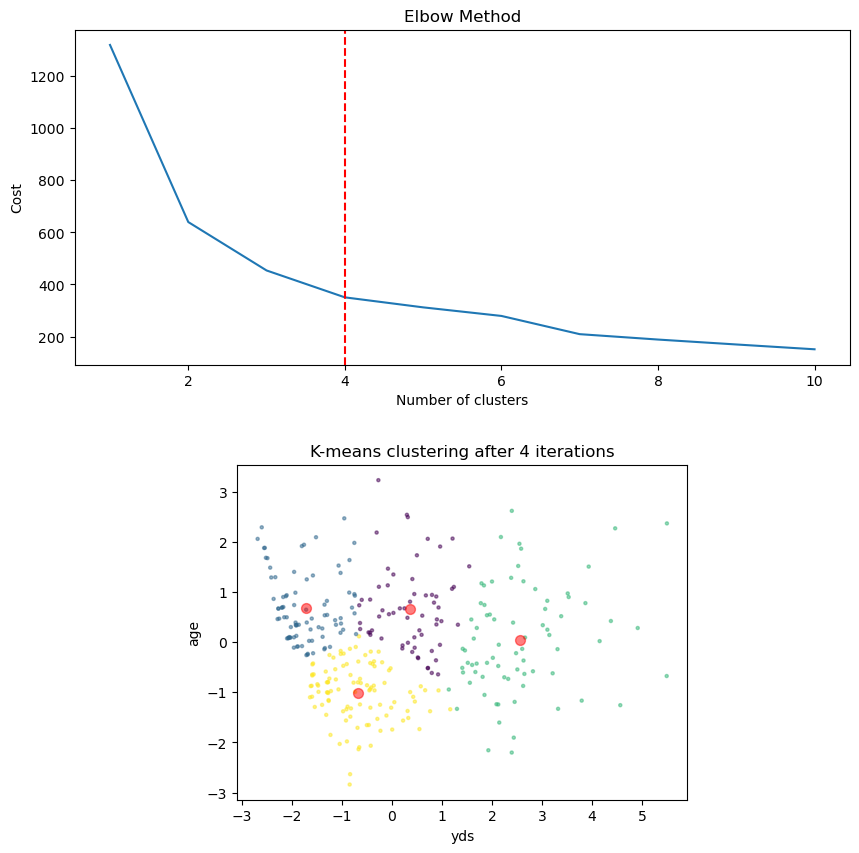

In [215]:
import plotly.graph_objs as go
from plotly.offline import iplot

df = WR_data.copy().drop("player_id", axis=1)
numeric_cols = df.select_dtypes(include="number").columns
stds = df[numeric_cols].std()
stds[stds == 0] = 1  # avoid divide-by-zero
df[numeric_cols] = (df[numeric_cols] - df[numeric_cols].mean()) / stds


def two_dim(df_pca, clusters):
    # reduce the dimensionality of the data
    # by finding the most important features
    pca = PCA(n_components=2)
    df_pca = pca.fit_transform(df.select_dtypes(include="number"))

    # finding important features
    dataset_pca = pd.DataFrame(
        abs(pca.components_),
        columns=df.select_dtypes(include="number").columns,
        index=["PC1", "PC2"],
    )

    # print the most important features
    print(f"X axis: {dataset_pca.idxmax(axis=1)[0]}")
    print(f"Y axis: {dataset_pca.idxmax(axis=1)[1]}")

    # find the best k
    costs = compute_elbow(df_pca, 10, 0, 1e-5)
    best_k = 4

    (centers, clusters, num_iterations) = calc_kmeans(df_pca, best_k, 0, 1e-5)

    plt.rcParams["figure.figsize"] = [10, 10]

    # plot costs vs k
    plt.subplot(211)
    plt.plot(range(1, 11), costs)
    plt.axvline(x=best_k, color="red", linestyle="--")
    plt.xlabel("Number of clusters")
    plt.ylabel("Cost")
    plt.title("Elbow Method")

    # plot the clusters
    plt.subplot(212)
    plt.gca().set_aspect("equal")
    plt.scatter(
        df_pca[:, 0],
        df_pca[:, 1],
        c=clusters,
        s=5,
        cmap="viridis",
        alpha=0.5,
    )
    plt.scatter(centers[:, 0], centers[:, 1], c="red", s=50, alpha=0.5)
    plt.xlabel(f"{dataset_pca.idxmax(axis=1)[0]}")
    plt.ylabel(f"{dataset_pca.idxmax(axis=1)[1]}")
    plt.title(f"K-means clustering after {num_iterations} iterations")

    # adjust the space between the plots
    plt.subplots_adjust(hspace=0.3)

    # add legend showing what each color represents
    # green = cluster 0, blue = cluster 1, etc
    # also get color from color map
    # yellow = mpatches.Patch(color=plt.cm.viridis(0.99), label="Slow + Low Mileage")
    # purple = mpatches.Patch(color=plt.cm.viridis(0), label="Fast + Various Mileage")
    # blue = mpatches.Patch(color=plt.cm.viridis(0.4), label="Fast + Low Mileage")
    # green = mpatches.Patch(color=plt.cm.viridis(0.6), label="Slow + High Mileage")
    # plt.legend(handles=[yellow, purple, blue, green])

    plt.show()


def three_dim(df_pca, clusters):
    # reduce the dimensionality of the data
    # by finding the most important features
    pca = PCA(n_components=3)
    df_pca = pca.fit_transform(df.select_dtypes(include="number"))

    # finding important features
    dataset_pca = pd.DataFrame(
        abs(pca.components_),
        columns=df.select_dtypes(include="number").columns,
        index=["PC1", "PC2", "PC3"],
    )

    # find the best k
    costs = compute_elbow(df_pca, 10, 0, 1e-5)
    best_k = 4

    # plot costs vs k
    plt.plot(range(1, 11), costs)
    plt.axvline(x=best_k, color="red", linestyle="--")
    plt.xlabel("Number of clusters")
    plt.ylabel("Cost")
    plt.title("Elbow Method")
    plt.show()

    (centers, clusters, num_iterations) = calc_kmeans(df_pca, best_k, 0, 1e-5)

    trace = go.Scatter3d(
        x=df_pca[:, 0],
        y=df_pca[:, 1],
        z=df_pca[:, 2],
        mode="markers",
        marker=dict(size=5, color=clusters, colorscale="Viridis", opacity=0.5),
    )

    iplot([trace])

    print(f"X axis: {dataset_pca.idxmax(axis=1)[0]}")
    print(f"Y axis: {dataset_pca.idxmax(axis=1)[1]}")
    print(f"Z axis: {dataset_pca.idxmax(axis=1)[2]}")


# uncomment each to run 2d graph and 3d graph

two_dim(df, 4)
# three_dim(df, 4)